In [1]:
import pandas as pd

df = pd.read_csv('telco_customer_churn_cleaned.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    'Contract',
    'InternetService',
    'TechSupport',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'StreamingTV',
    'StreamingMovies'
]

encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

encoded_features = encoder.fit_transform(df[categorical_features])

encoded_features.shape

(7043, 24)

In [4]:
import numpy as np

numerical_features = [
    'SeniorCitizen',
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

X_numerical = df[numerical_features].values

X = np.hstack([X_numerical, encoded_features])

X.shape

(7043, 28)

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled.shape

(7043, 28)

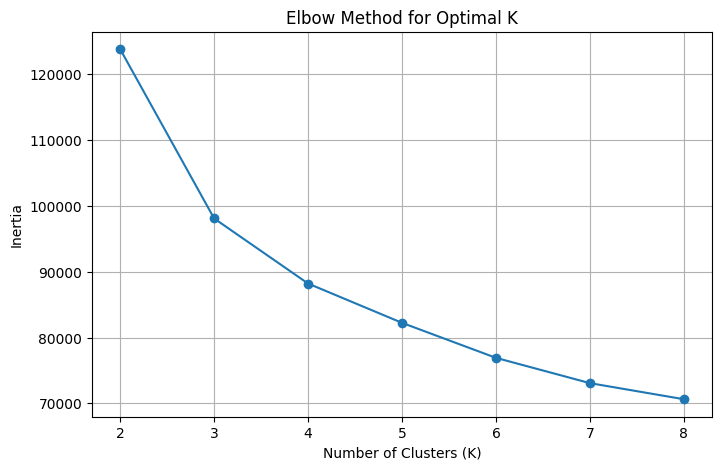

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_values = []

K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(K_range, inertia_values, marker='o')

plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.xticks(K_range)
plt.grid(True)

plt.show()

In [7]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

cluster_labels[:10]

array([2, 2, 2, 0, 2, 2, 2, 2, 0, 0], dtype=int32)

In [8]:
df['Cluster'] = cluster_labels

df[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Cluster']].head(10)

,customerID,tenure,MonthlyCharges,TotalCharges,Cluster
0,7590-VHVEG,1,29.85,29.85,2
1,5575-GNVDE,34,56.95,1889.50,2
2,3668-QPYBK,2,53.85,108.15,2
3,7795-CFOCW,45,42.30,1840.75,0
4,9237-HQITU,2,70.70,151.65,2
5,9305-CDSKC,8,99.65,820.50,2
6,1452-KIOVK,22,89.10,1949.40,2
7,6713-OKOMC,10,29.75,301.90,2
8,7892-POOKP,28,104.80,3046.05,0
9,6388-TABGU,62,56.15,3487.95,0


In [9]:
cluster_counts = df['Cluster'].value_counts().sort_index()

cluster_counts

,count
Cluster,
0,2330
1,1526
2,3187


In [10]:
cluster_profile = df.groupby('Cluster')[
    ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
].mean()

cluster_profile

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
Cluster,,,,
0,0.170815,54.218884,87.060837,4772.095601
1,0.034076,30.547182,21.079194,662.604784
2,0.217132,17.271729,69.374961,1231.895529


In [11]:
cluster_churn_rate = pd.crosstab(
    df['Cluster'],
    df['Churn'],
    normalize='index'
) * 100

cluster_churn_rate

Churn,No,Yes
Cluster,,
0,86.223176,13.776824
1,92.595020,7.404980
2,54.973329,45.026671


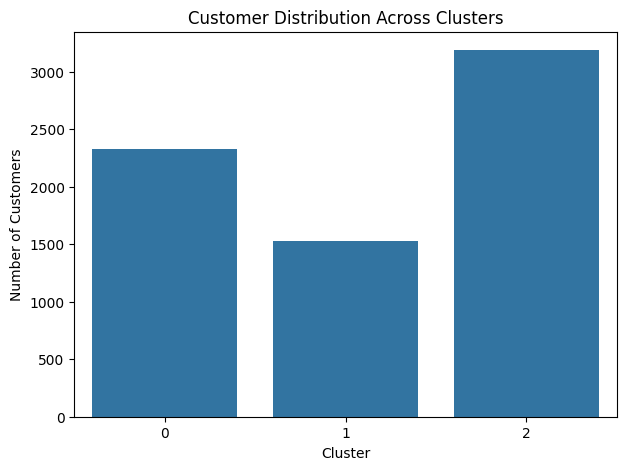

In [13]:
import seaborn as sns
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Cluster')

plt.title('Customer Distribution Across Clusters')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')

plt.show()

In [14]:
cluster_profile

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
Cluster,,,,
0,0.170815,54.218884,87.060837,4772.095601
1,0.034076,30.547182,21.079194,662.604784
2,0.217132,17.271729,69.374961,1231.895529


In [15]:
cluster_internet = pd.crosstab(
    df['Cluster'],
    df['InternetService'],
    normalize='index'
) * 100

cluster_internet

InternetService,DSL,Fiber optic,No
Cluster,,,
0,46.781116,53.218884,0.0
1,0.000000,0.000000,100.0
2,41.763414,58.236586,0.0


In [16]:
cluster_contract = pd.crosstab(
    df['Cluster'],
    df['Contract'],
    normalize='index'
) * 100

cluster_contract

Contract,Month-to-month,One year,Two year
Cluster,,,
0,17.896996,38.369099,43.733906
1,34.338139,23.853211,41.808650
2,92.061500,6.746156,1.192344


In [17]:
cluster_summary = cluster_profile.copy()

cluster_summary['Customers'] = cluster_counts
cluster_summary['Churn_Rate'] = cluster_churn_rate['Yes']

cluster_summary = cluster_summary[
    ['Customers', 'SeniorCitizen', 'tenure',
     'MonthlyCharges', 'TotalCharges', 'Churn_Rate']
]

cluster_summary

,Customers,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn_Rate
Cluster,,,,,,
0,2330,0.170815,54.218884,87.060837,4772.095601,13.776824
1,1526,0.034076,30.547182,21.079194,662.604784,7.404980
2,3187,0.217132,17.271729,69.374961,1231.895529,45.026671


## Customer Segment Interpretation

### Cluster 0 — Long-Term, High-Value Customers
Cluster 0 contains 2,330 customers. These customers have the highest average tenure at 54.22 months, the highest average monthly charges at 87.06, and the highest average total charges at 4,772.10. The cluster also has a relatively low observed churn rate of 13.78%. Its contract composition is dominated by longer-term contracts, with 43.73% having two-year contracts and 38.37% having one-year contracts.

### Cluster 1 — Low-Charge, Non-Internet Customers
Cluster 1 contains 1,526 customers and has the lowest average monthly charges at 21.08 and lowest average total charges at 662.60. Its average tenure is 30.55 months. The InternetService analysis shows that 100% of customers in this cluster have no internet service. The observed churn rate is 7.40%.

### Cluster 2 — Newer, Month-to-Month Customers
Cluster 2 is the largest segment, containing 3,187 customers. It has the shortest average tenure at 17.27 months and an average monthly charge of 69.37. Approximately 92.06% of customers in this cluster have month-to-month contracts, while 58.24% use Fiber optic internet service. This cluster has the highest observed churn rate at 45.03%.

### Overall Cluster Insight

The clustering analysis identified three distinct customer segments based on customer characteristics, services, tenure, and billing information. Cluster 2 is particularly notable because it combines shorter average tenure with a very high proportion of month-to-month contracts and has the highest observed churn rate. These patterns can help guide further customer-retention analysis and targeted business strategies. The observed relationships are associations within the dataset and should not be interpreted as proof of causation.